In [1]:
!pip install --upgrade pip
#instalacja pakietu gdown
!pip install -U --no-cache-dir gdown==4.6.0 --pre
#usuwanie i tworzenie pustego katalogu data
!rm -rf data && mkdir data
#pobieranie zip-a ze zdjęciami
!gdown 1TipvNHelI7FZKCD4d8pWXpz2a5Lqvbui -O data.zip
#rozpakowywanie pliku data.zip do katalogu data
!unzip -q data.zip -d data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.0
    Uninstalling gdown-5.2.0:
      Successfully uninstalled gdown-5.2.0
Downloading...
From: https://drive.google.com/uc?id=1TipvNHelI7FZKCD4d8pWXpz2a5Lqvbui
To: /content/data.zip
100% 2.95M/2.95M [00:00<00:00, 42.8MB/s]


In [ ]:
import os
import glob

# List all files in the target directory and its subdirectories
all_files = glob.glob('data/sztuczna/**/*', recursive=True)

print("All files found in data/sztuczna:")
for file_path in all_files:
    # Check if the path is a file (not a directory)
    if os.path.isfile(file_path):
        # Check if the file extension is not .jpg (case-insensitive)
        if not file_path.lower().endswith('.jpg'):
            print(f"Potential non-JPG or problematic file: {file_path}")

print("\nFinished checking files.")

All files found in data/sztuczna:

Finished checking files.


In [ ]:
import os
from PIL import Image

bad_files = []
root_dir = 'data/sztuczna'

for root, dirs, files in os.walk(root_dir):
    for name in files:
        path = os.path.join(root, name)
        try:
            img = Image.open(path)
            img.verify()  # weryfikacja obrazu bez ładowania do pamięci
        except (IOError, SyntaxError):
            bad_files.append(path)

print(f'Znaleziono {len(bad_files)} błędnych plików:')
for path in bad_files:
    print(f'❌ {path}')

Znaleziono 0 błędnych plików:


In [1]:
import glob
image_count = len(list(glob.glob('data/**/**/*.jpg')))
print(f'{image_count} examples of balls')

0 examples of balls


baseline

Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.
Wykryte klasy: ['kosz', 'nozna', 'siatka', 'tenis']
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 62s 6s/step - accuracy: 0.1696 - loss: 2.5390 - val_accuracy: 0.3810 - val_loss: 10.6984
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.4773 - loss: 2.8625 - val_accuracy: 0.3810 - val_loss: 9.1238
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.6170 - loss: 1.1710 - val_accuracy: 0.3810 - val_loss: 42.0257
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.8155 - loss: 0.4043 - val_accuracy: 0.3810 - val_loss: 97.1216
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.9232 - loss: 0.2291 - val_accuracy: 0.3810 - val_loss: 181.1138
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step - accuracy: 0.9940 - loss: 0.0431 - val_accuracy: 0.3810 - val_loss: 261.4186
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accurac

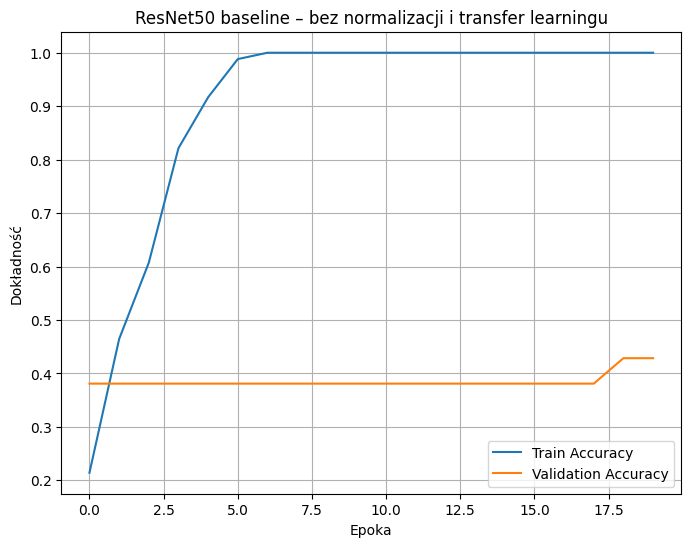

In [5]:
# 📦 Importy
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt
import time
import os
import glob



# 🔧 Ustawienia obrazu
img_height, img_width = 64, 64
batch_size = 32

# 📁 Wczytywanie danych treningowych i walidacyjnych

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 🔢 Liczba klas
class_names = train_ds.class_names
class_count = len(class_names)
print(f'Wykryte klasy: {class_names}')

# ⚙️ Przyspieszenie ładowania danych
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 🧠 Tworzenie modelu ResNet50 od zera (bez pre-trained, bez transfer learningu)
base_model = ResNet50(include_top=False, weights=None, input_shape=(img_height, img_width, 3))

model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(class_count, activation='softmax')
])

# 🧪 Kompilacja
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ⏱️ Trening z pomiarem czasu
epochs = 20
start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)
end = time.time()

# 📊 Wyniki
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
training_time = end - start

print("\n📌 BASELINE – ResNet50 trenowany od zera (bez normalizacji, augmentacji, dropoutów, transfer learningu)")
print("Czas treningu: {:.2f} sekund".format(training_time))
print("Dokładność treningowa: {:.2f}%".format(train_acc * 100))
print("Dokładność walidacyjna: {:.2f}%".format(val_acc * 100))

# 📈 Wykres dokładności
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 baseline – bez normalizacji i transfer learningu')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

transfer learning

Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.
Wykryte klasy: ['kosz', 'nozna', 'siatka', 'tenis']
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.4139 - loss: 1.3826 - val_accuracy: 0.7619 - val_loss: 0.4521
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8071 - loss: 0.4488 - val_accuracy: 0.9048 - val_loss: 0.3146
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.1004 - val_accuracy: 0.9048 - val_loss: 0.4679
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 0.0570 - val_accuracy: 0.9048 - val_loss: 0.5477
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.0480 - val_accuracy: 0.9048 - val_loss: 0.4474
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 0.0162 - val_accuracy: 0.9048 - val_loss: 0.3822
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accura

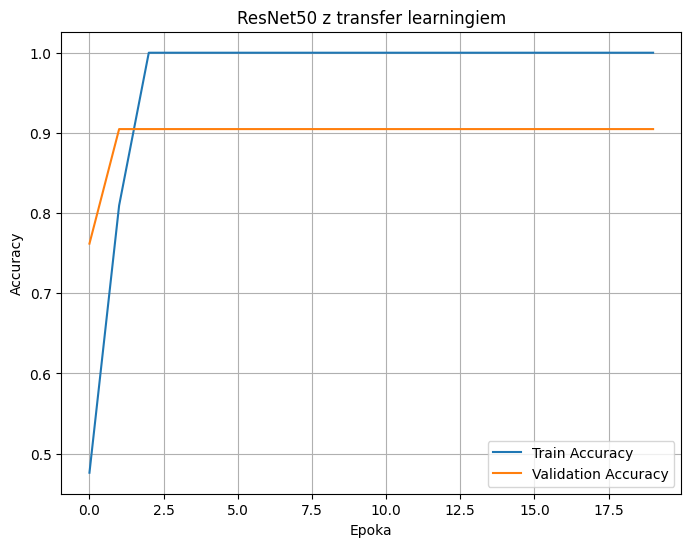

In [38]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Sequential
import tensorflow as tf
import time
import matplotlib.pyplot as plt

# 🔧 Nowy rozmiar obrazu dla ResNet50 (zgodny z wymaganiami ImageNet)
img_height, img_width = 224, 224
batch_size = 32

# 📁 Ładowanie danych
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 🔢 Klasy
class_names = train_ds.class_names
class_count = len(class_names)
print(f'Wykryte klasy: {class_names}')

# ⚙️ Prefetch/cache dla wydajności
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 🧠 Transfer learning z ResNet50 (zamrożony)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Zamrażamy warstwy bazowe

model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(class_count, activation='softmax')
])

# 🧪 Kompilacja
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ⏱️ Trening
epochs = 20
start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)
end = time.time()

# 📊 Wyniki
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
training_time = end - start

print("\n📌 TRANSFER LEARNING – ResNet50 (zamrożony)")
print("Czas treningu: {:.2f} s".format(training_time))
print("Dokładność treningowa: {:.2f}%".format(train_acc * 100))
print("Dokładność walidacyjna: {:.2f}%".format(val_acc * 100))

# Wykres
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 z transfer learningiem')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


normalizacja

Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.
Wykryte klasy: ['kosz', 'nozna', 'siatka', 'tenis']
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.1467 - loss: 2.5567 - val_accuracy: 0.1429 - val_loss: 1.4273
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.2690 - loss: 1.1960 - val_accuracy: 0.4762 - val_loss: 1.0386
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.3351 - loss: 1.1617 - val_accuracy: 0.2857 - val_loss: 1.1071
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4313 - loss: 1.0528 - val_accuracy: 0.1429 - val_loss: 1.2758
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4517 - loss: 1.0660 - val_accuracy: 0.4762 - val_loss: 1.1753
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4803 - loss: 1.0076 - val_accuracy: 0.4762 - val_loss: 1.0090
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accur

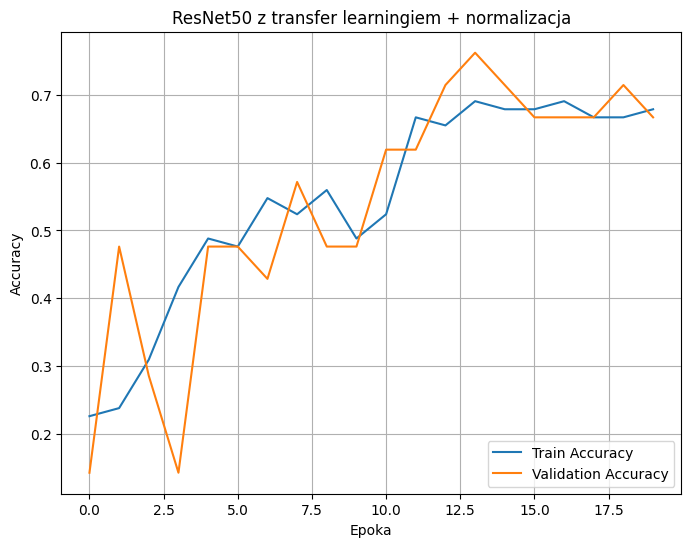

In [40]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Sequential
import tensorflow as tf
import time
import matplotlib.pyplot as plt

# 🔧 Nowy rozmiar obrazu dla ResNet50 (zgodny z wymaganiami ImageNet)
img_height, img_width = 224, 224
batch_size = 32

# 📁 Ładowanie danych
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 🔢 Klasy
class_names = train_ds.class_names
class_count = len(class_names)
print(f'Wykryte klasy: {class_names}')

# ⚙️ Prefetch/cache dla wydajności
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 🧠 Transfer learning z ResNet50 (zamrożony)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Zamrażamy warstwy bazowe

# ✅ MODEL z normalizacją
model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),  # 🔹 Normalizacja
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(class_count, activation='softmax')
])

# 🧪 Kompilacja
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ⏱️ Trening
epochs = 20
start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)
end = time.time()

# 📊 Wyniki
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
training_time = end - start

print("\n📌 TRANSFER LEARNING – ResNet50 (zamrożony) z normalizacją")
print("Czas treningu: {:.2f} s".format(training_time))
print("Dokładność walidacyjna: {:.2f}%".format(val_acc * 100))

# 📈 Wykres
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 z transfer learningiem + normalizacja')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


z augmentacja

Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.
Wykryte klasy: ['kosz', 'nozna', 'siatka', 'tenis']
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4611 - loss: 1.4359 - val_accuracy: 0.7143 - val_loss: 0.5528
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9094 - loss: 0.3641 - val_accuracy: 0.9048 - val_loss: 0.4443
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9767 - loss: 0.1455 - val_accuracy: 0.9048 - val_loss: 0.4175
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 0.0539 - val_accuracy: 0.9048 - val_loss: 0.4727
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 0.9048 - val_loss: 0.4838
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 0.9048 - val_loss: 0.4827
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - ac

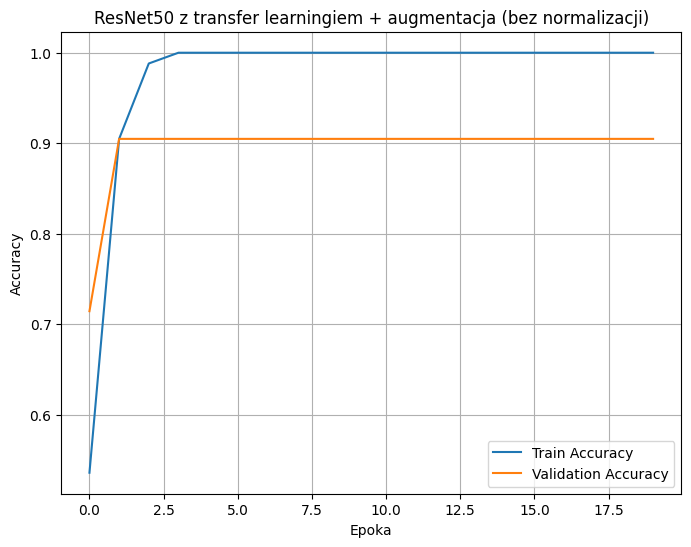

In [41]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Sequential
import tensorflow as tf
import time
import matplotlib.pyplot as plt

# 🔧 Rozmiar obrazu zgodny z wymaganiami ResNet50
img_height, img_width = 224, 224
batch_size = 32

# 📁 Wczytywanie danych
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 🔢 Klasy
class_names = train_ds.class_names
class_count = len(class_names)
print(f'Wykryte klasy: {class_names}')

# ⚙️ Przyspieszenie danych
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 🔄 Warstwy augmentacji
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 🧠 Transfer learning z ResNet50 (zamrożony)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Zamrożenie wag

# 🔧 Model z augmentacją (bez normalizacji)
model = Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(class_count, activation='softmax')
])

# 🧪 Kompilacja
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ⏱️ Trening
epochs = 20
start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)
end = time.time()

# 📊 Wyniki
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
training_time = end - start

print("\n📌 TRANSFER LEARNING – ResNet50 (zamrożony) z augmentacją (bez normalizacji)")
print("Czas treningu: {:.2f} s".format(training_time))
print("Dokładność treningowa: {:.2f}%".format(train_acc * 100))
print("Dokładność walidacyjna: {:.2f}%".format(val_acc * 100))

# 📈 Wykres
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 z transfer learningiem + augmentacja (bez normalizacji)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


z augmentacją

Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.
Wykryte klasy: ['kosz', 'nozna', 'siatka', 'tenis']
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.3443 - loss: 1.4704 - val_accuracy: 0.7619 - val_loss: 0.6246
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8288 - loss: 0.5612 - val_accuracy: 0.9048 - val_loss: 0.3865
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8467 - loss: 0.4069 - val_accuracy: 0.9048 - val_loss: 0.2962
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8258 - loss: 0.3549 - val_accuracy: 0.9048 - val_loss: 0.2806
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9510 - loss: 0.1792 - val_accuracy: 0.9048 - val_loss: 0.3700
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9567 - loss: 0.1126 - val_accuracy: 0.9048 - val_loss: 0.5422
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accurac

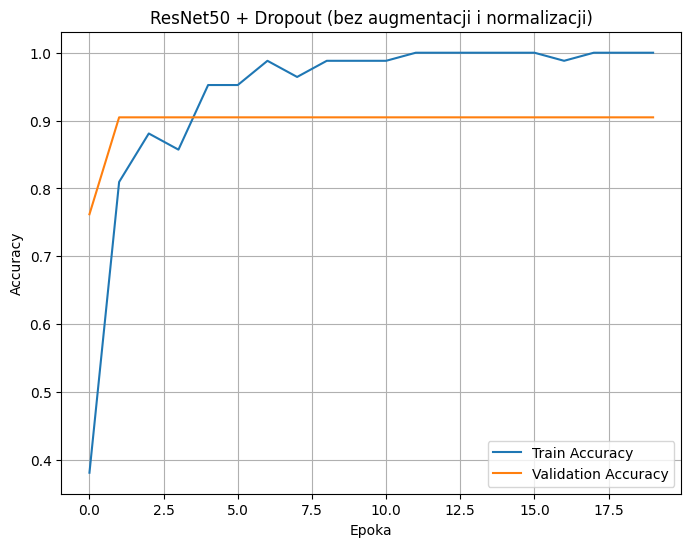

In [42]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Sequential
import tensorflow as tf
import time
import matplotlib.pyplot as plt

# 🔧 Rozmiar obrazu dla ResNet50
img_height, img_width = 224, 224
batch_size = 32

# 📁 Wczytywanie danych
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 🔢 Klasy
class_names = train_ds.class_names
class_count = len(class_names)
print(f'Wykryte klasy: {class_names}')

# ⚙️ Prefetch/cache dla wydajności
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 🧠 Transfer learning – zamrożona baza ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False

# 🔧 Model z Dropoutem
model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # ⛔ Dropout zapobiega przeuczeniu
    layers.Dense(class_count, activation='softmax')
])

# 🧪 Kompilacja
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ⏱️ Trening
epochs = 20
start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)
end = time.time()

# 📊 Wyniki
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
training_time = end - start

print("\n📌 TRANSFER LEARNING – ResNet50 (zamrożony) + Dropout (bez augmentacji, bez normalizacji)")
print("Czas treningu: {:.2f} s".format(training_time))
print("Dokładność treningowa: {:.2f}%".format(train_acc * 100))
print("Dokładność walidacyjna: {:.2f}%".format(val_acc * 100))

# 📈 Wykres
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 + Dropout (bez augmentacji i normalizacji)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


testowanie roznych rozmiarow image



🔍 Testowanie rozmiaru wejściowego: 96x96
Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.

🔍 Testowanie rozmiaru wejściowego: 160x160
Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.

🔍 Testowanie rozmiaru wejściowego: 224x224
Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.

📈 WYNIKI PORÓWNAWCZE:
96x96: Train Acc = 100.00%, Val Acc = 85.71%, Czas = 30.16s
160x160: Train Acc = 100.00%, Val Acc = 90.48%, Czas = 26.00s
224x224: Train Acc = 100.00%, Val Acc = 90.48%, Czas = 23.42s


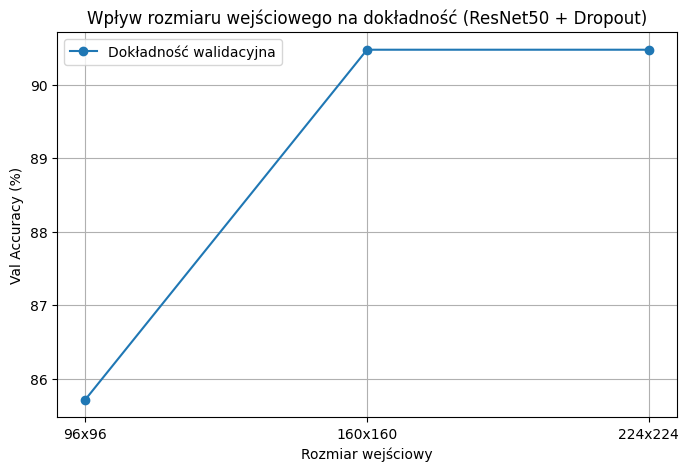

In [44]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Sequential
import time
import matplotlib.pyplot as plt

# 🧪 Testowane rozmiary
input_sizes = [(96, 96), (160, 160), (224, 224)]
batch_size = 32
epochs = 20  # Możesz zwiększyć, jeśli chcesz dokładniejsze porównanie

results = []

for img_height, img_width in input_sizes:
    print(f"\n🔍 Testowanie rozmiaru wejściowego: {img_height}x{img_width}")

    # 📁 Ładowanie danych
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        'data/sztuczna',
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        'data/sztuczna',
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    class_count = len(train_ds.class_names)

    # ⚙️ Prefetch/cache
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    # 🧠 ResNet50 z dropoutem (zamrożony)
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(class_count, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # ⏱️ Trening
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0)
    end = time.time()

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    training_time = end - start

    results.append({
        'input_size': f'{img_height}x{img_width}',
        'train_acc': train_acc,
        'val_acc': val_acc,
        'time': training_time
    })

# 📊 Podsumowanie
print("\n📈 WYNIKI PORÓWNAWCZE:")
for r in results:
    print(f"{r['input_size']}: "
          f"Train Acc = {r['train_acc']*100:.2f}%, "
          f"Val Acc = {r['val_acc']*100:.2f}%, "
          f"Czas = {r['time']:.2f}s")

# 📉 Wykres dokładności walidacyjnej
plt.figure(figsize=(8, 5))
plt.plot([r['input_size'] for r in results],
         [r['val_acc']*100 for r in results],
         marker='o', label='Dokładność walidacyjna')
plt.title('Wpływ rozmiaru wejściowego na dokładność (ResNet50 + Dropout)')
plt.xlabel('Rozmiar wejściowy')
plt.ylabel('Val Accuracy (%)')
plt.grid(True)
plt.legend()
plt.show()


testowanie roznych rozmiarow batch size



🧪 Testowanie batch_size = 32
Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.

🧪 Testowanie batch_size = 64
Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.

🧪 Testowanie batch_size = 128
Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.

📈 PODSUMOWANIE – wpływ batch_size:
Batch: 32 → Train Acc: 100.00%, Val Acc: 90.48%, Time: 24.07s
Batch: 64 → Train Acc: 100.00%, Val Acc: 90.48%, Time: 23.43s
Batch: 128 → Train Acc: 97.62%, Val Acc: 90.48%, Time: 104.64s


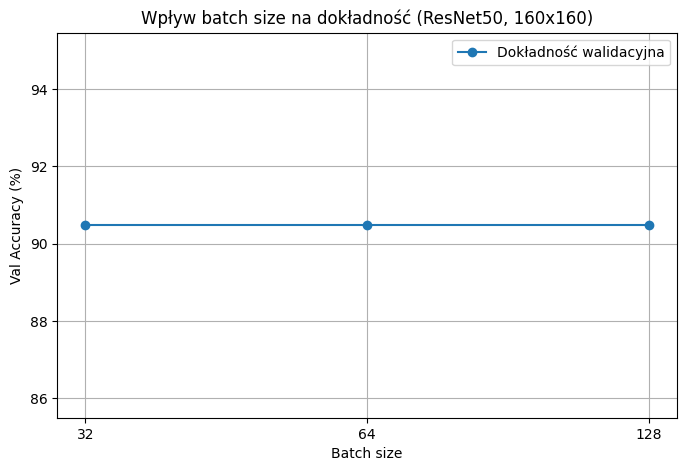

In [46]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Sequential
import time
import matplotlib.pyplot as plt

# 🔧 Parametry wejściowe
img_height, img_width = 224, 224
batch_sizes = [32, 64, 128]
epochs = 20  # Możesz wydłużyć przy większych batchach

results = []

for batch_size in batch_sizes:
    print(f"\n🧪 Testowanie batch_size = {batch_size}")

    # 📁 Dane
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        'data/sztuczna',
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        'data/sztuczna',
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    class_count = len(train_ds.class_names)

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    # 🧠 Model: ResNet50 + Dropout
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(class_count, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # ⏱️ Trening
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0)
    end = time.time()

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    training_time = end - start

    results.append({
        'batch_size': batch_size,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'time': training_time
    })

# 📊 Wyniki
print("\n📈 PODSUMOWANIE – wpływ batch_size:")
for r in results:
    print(f"Batch: {r['batch_size']} → Train Acc: {r['train_acc']*100:.2f}%, "
          f"Val Acc: {r['val_acc']*100:.2f}%, Time: {r['time']:.2f}s")

# 📉 Wykres
plt.figure(figsize=(8, 5))
plt.plot([str(r['batch_size']) for r in results],
         [r['val_acc']*100 for r in results],
         marker='o', label='Dokładność walidacyjna')
plt.title('Wpływ batch size na dokładność (ResNet50, 160x160)')
plt.xlabel('Batch size')
plt.ylabel('Val Accuracy (%)')
plt.grid(True)
plt.legend()
plt.show()


testowanie roznych struktur sieci

Found 105 files belonging to 4 classes.
Using 84 files for training.
Found 105 files belonging to 4 classes.
Using 21 files for validation.

🔧 Trening architektury: VGG16

🔧 Trening architektury: ResNet101
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

🔧 Trening architektury: InceptionV3
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔧 Trening architektury: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📈 PODSUMOWANIE – różne architektury:
VGG16        → Train Acc: 100.00%, Val Acc: 90.48%, Time: 43.57s
ResNet101    → Train Acc: 100.00%, Val Acc: 95.24%, Time: 46.50s
InceptionV3  → Train Acc: 66.67%, Val Acc: 61.90%, Time: 37.45s
MobileNetV2  → Train Acc: 97.62%, Val Acc: 85.71%, Time: 21.14s


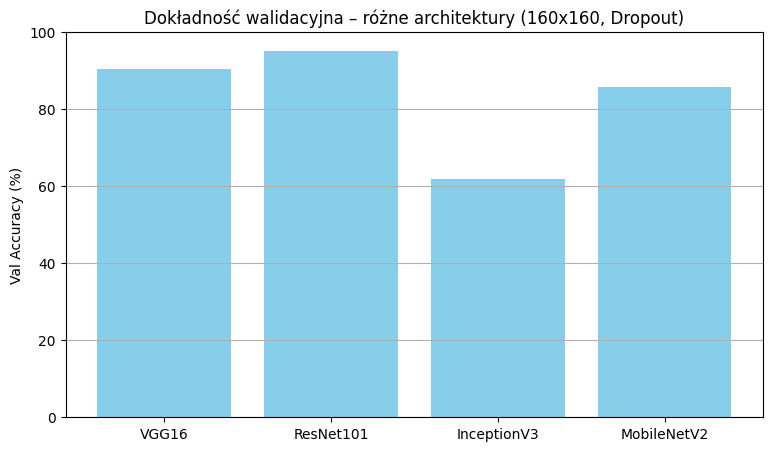

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import (
    VGG16, ResNet101, InceptionV3, MobileNetV2
)
import time
import matplotlib.pyplot as plt

# 📐 Parametry
img_height, img_width = 224, 224
batch_size = 32
epochs = 20
architectures = {
    "VGG16": VGG16,
    "ResNet101": ResNet101,
    "InceptionV3": InceptionV3,
    "MobileNetV2": MobileNetV2
}

# 📁 Dane
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data/sztuczna',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_count = len(train_ds.class_names)

# 🔁 Przyspieszenie
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 🔬 Eksperymenty
results = []

for name, Arch in architectures.items():
    print(f"\n🔧 Trening architektury: {name}")

    try:
        base_model = Arch(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    except Exception as e:
        print(f"❌ Pominięto {name} – błąd inicjalizacji: {e}")
        continue

    base_model.trainable = False

    model = Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(class_count, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0)
    end = time.time()

    results.append({
        'model': name,
        'train_acc': history.history['accuracy'][-1],
        'val_acc': history.history['val_accuracy'][-1],
        'time': end - start
    })

# 📊 Wyniki
print("\n📈 PODSUMOWANIE – różne architektury:")
for r in results:
    print(f"{r['model']:12} → Train Acc: {r['train_acc']*100:.2f}%, "
          f"Val Acc: {r['val_acc']*100:.2f}%, Time: {r['time']:.2f}s")

# 📉 Wykres dokładności
plt.figure(figsize=(9, 5))
plt.bar([r['model'] for r in results],
        [r['val_acc']*100 for r in results],
        color='skyblue')
plt.title("Dokładność walidacyjna – różne architektury (160x160, Dropout)")
plt.ylabel("Val Accuracy (%)")
plt.grid(axis='y')
plt.show()
